## Reference Data: Allen Brain Atlas — Mouse V1 & ALM Smart-seq

Single-cell RNA-seq transcriptomic dataset from the Allen Cell Types Database, profiling cells from mouse primary visual cortex (VISp / V1) and anterior lateral motor cortex (ALM).

- **Species:** Mouse (*Mus musculus*)
- **Brain regions:** Primary visual cortex (VISp, 14,249 cells) and anterior lateral motor cortex (ALM, 9,573 cells) — **23,822 cells total**
- **Method:** Smart-seq full-length scRNA-seq
- **Cell types:** 133 transcriptomic types total
  - 56 glutamatergic (excitatory) neuron types — mostly region-specific
  - 61 GABAergic (inhibitory) neuron types — mostly shared across regions
  - 16 non-neuronal types — mostly shared across regions
- **Source:** [Allen Brain Map — Mouse V1 and ALM Smart-seq](https://brain-map.org/our-research/cell-types-taxonomies/cell-types-database-rna-seq-data/mouse-v1-and-alm-smart-seq)

VISp and ALM represent distant poles of the neocortex with distinct functions, making this dataset well-suited for studying transcriptional diversity and region-specific cell type organization. Used here as a reference taxonomy for annotating HCR/FISH spatial data.

---

## Subclass Exclusions

The following subclasses are excluded from analysis:

| Subclass | Reason |
|----------|--------|
| Astro | Astrocytes — non-neuronal glial cells |
| Oligo | Oligodendrocytes — non-neuronal glial cells |
| Endo | Endothelial cells — vascular, non-neuronal |
| Peri | Pericytes — vascular, non-neuronal |
| VLMC | Vascular leptomeningeal cells — non-neuronal |
| SMC | Smooth muscle cells — vascular, non-neuronal |
| Macrophage | Immune cells — non-neuronal |
| Doublet | Two cells captured together — sequencing artifact |
| Low Quality | Failed QC thresholds — low reads or gene detection |
| No Class | Outlier or donor-specific cluster — unassignable |


bain_subregion
	"L1"
	"L1-L2/3"
	"L1-L4"
	"L1-L6"
	"L2/3"
	"L2/3-L4"
	"L4"
	"L4-L5"
	"L4-L6"
	"L5"
	"L5-L6"
	"L6"
	"L6b"

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import seaborn as sns

from aind_hcr_data_loader import get_hcr_dataset_pairwise
import pandas as pd

import aind_hcr_qc.viz as viz

import importlib
importlib.reload(viz)


import sys, importlib
sys.path.insert(0, '/root/capsule/code/cluster_validation')
#import atlas_compare

import cluster_validation_utils



ModuleNotFoundError: No module named 'cluster_validation_utils'

In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [ ]:
dataset, pw_ds, _ = get_hcr_dataset_pairwise(
    mouse_id="788406",
    data_dir=Path("/root/capsule/data"),   # default
    load_spots=False,                        # default
    return_removed=False,                    # include removed spots with a 'removed' column
    coreg_cells_only=False,                     # only load coregistered cells
)

  [rounds.R1]  HCR_790322_2025-11-05_13-00-00_processed_2025-11-10_20-36-20  →  ✓ attached
  [rounds.R2]  HCR_790322_2025-11-12_13-00-00_processed_2025-11-13_22-03-58  →  ✓ attached
  [rounds.R3]  HCR_790322_2025-11-19_13-00-00_processed_2025-11-21_01-31-13  →  ✓ attached
  [rounds.R4]  HCR_790322_2025-12-04_13-00-00_processed_2025-12-05_22-49-47  →  ✓ attached
  [rounds.R5]  HCR_790322_2025-12-11_13-00-00_processed_2025-12-12_23-47-08  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_790322_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_790322_cell-typing_2026-03-11_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_790322_pairwise-unmixing_2026-05-23_17-43-06  →  ✓ attached
  [derived_assets.czstack_hcr_coreg]  790322_2025-07-10_ctl-czstack-hcr-coreg_2026-03-02_00-00-00  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_790322_2025-11-05_13-00-00_processed_2

In [4]:
cxg_inh_df = pw_ds.load_inhibitory_cells(unmixed=True,all_spots=False)
cxg_inh_ad = pw_ds.load_inhibitory_cells(unmixed=True,all_spots=False, as_anndata=True)
coreg_df = dataset.load_coreg_table()

In [5]:
ss_path = "/root/capsule/scratch/mouse_VISp_gene_expression_matrices_2018-06-14"

hcr_genes = cxg_inh_ad.var_names
hcr_genes = hcr_genes[hcr_genes != 'GFP']

smartseq_data = cluster_validation_utils.load_visp_expression(ss_path, genes=hcr_genes, layer="exon")


In [6]:
gene_cols = smartseq_data.var_names.tolist()

# CPM: normalize each cell's counts to sum to 1e6
smartseq_data_cpm = smartseq_data.copy()
sc.pp.normalize_total(smartseq_data_cpm, target_sum=1e6)

# log2(CPM + 1)
smartseq_data_log = smartseq_data_cpm.copy()
sc.pp.log1p(smartseq_data_log, base=2)


filtered_log = cluster_validation_utils.make_filtered_views_for_smartseq(smartseq_data_log)
filtered_cpm = cluster_validation_utils.make_filtered_views_for_smartseq(smartseq_data_cpm)

# inhibitory cells
adata_log_inh = filtered_log["inhibitory"]
cxg_inh = pd.DataFrame(adata_log_inh.X, columns=adata_log_inh.var_names, index=adata_log_inh.obs_names)



# Plotting basic

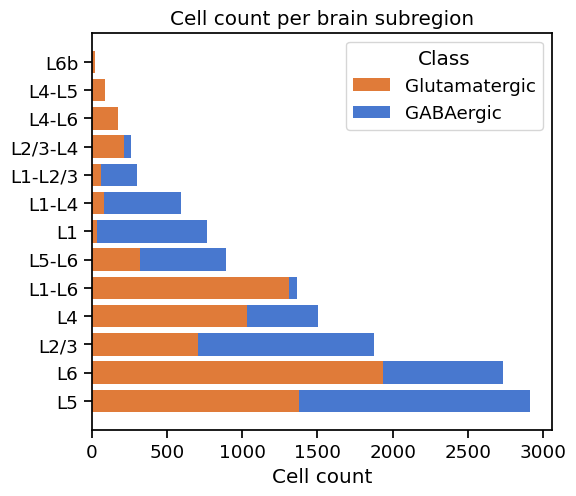

In [32]:
fig = cluster_validation_utils.plot_cell_count_by_subregion(smartseq_data)
plt.show()


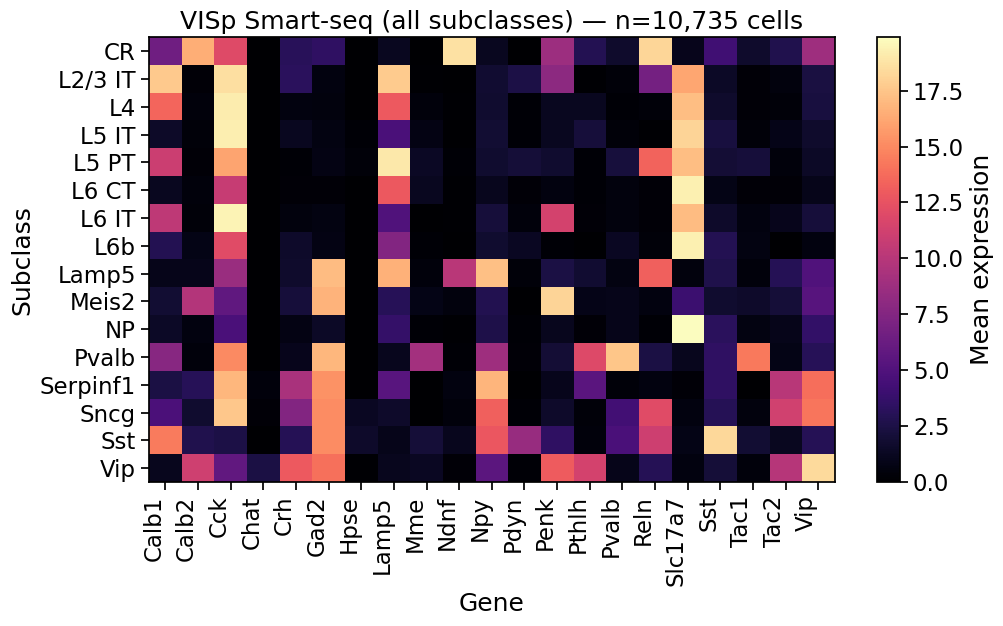

In [ ]:
sns.set_context("notebook", font_scale=1.5)



fig =  cluster_validation_utils.plot_subclass_heatmap(filtered_log["all"], title=f"VISp Smart-seq (all subclasses) — n={len(filtered_log['all']):,} cells")
plt.show()


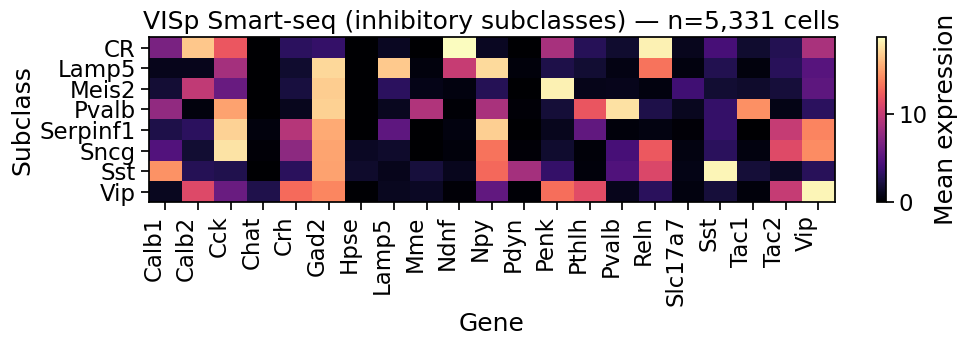

In [38]:
fig = cluster_validation_utils.plot_subclass_heatmap(filtered_log["inhibitory"], 
                            title=f"VISp Smart-seq (inhibitory subclasses) — n={len(filtered_log['inhibitory']):,} cells")
plt.show()


# Plot cell x gene

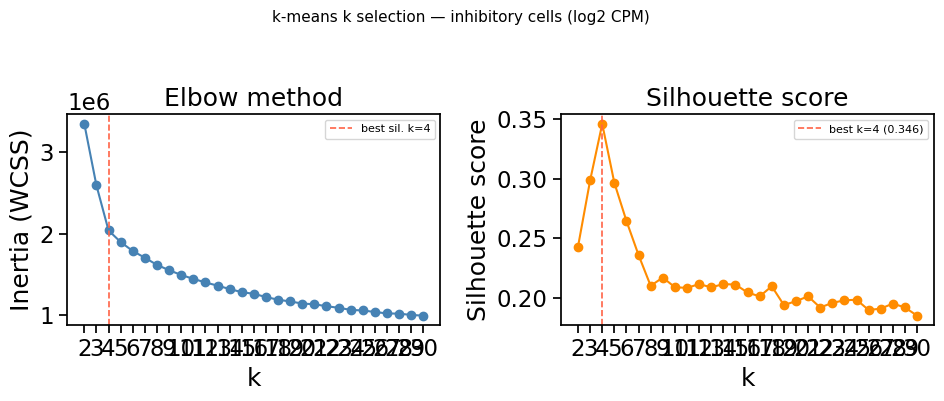

Best k (silhouette): 4


In [11]:
import pandas as pd
import importlib
import aind_hcr_qc.viz as viz
importlib.reload(viz)

adata_log_inh = filtered_log["inhibitory"]
cxg_inh = pd.DataFrame(adata_log_inh.X, columns=adata_log_inh.var_names, index=adata_log_inh.obs_names)

fig, k_results = viz.plot_kmeans_k_selection(
    cxg_inh,
    k_range=(2, 30),
    clip_range=(0, 5000),
    title="k-means k selection — inhibitory cells (log2 CPM)",
)
plt.show()
print(f"Best k (silhouette): {k_results['best_k_silhouette']}")


In [ ]:
import pandas as pd
import importlib
import aind_hcr_qc.viz as viz
importlib.reload(viz)

adata_log_inh = filtered_log["inhibitory"]
cxg_inh = pd.DataFrame(adata_log_inh.X, columns=adata_log_inh.var_names, index=adata_log_inh.obs_names)

fig, sorted_ids = viz.plot_cell_x_gene_hierarchical(
    cxg_inh,
    clip_range=(0, 5000),
    row_cluster=True,
    col_cluster=False,    # keep genes alphabetical
    linkage_method='ward',
    metric='correlation',
    fig_size=(7, 12),
    title="VISp Smart-seq inhibitory cells — hierarchical clustering (log2 CPM)",
)
plt.show()


(<Figure size 700x1000 with 2 Axes>,
 array([ 0,  0,  0, ..., 19, 19, 19], shape=(5331,)),
 Index(['F1S4_160108_002_H01', 'F1S4_160108_001_D01', 'F1S4_160108_004_D01',
        'F2S4_160115_026_H01', 'FYS4_171003_504_D01', 'F1S4_160108_006_E01',
        'F2S4_170807_009_A01', 'F2S4_170807_006_G01', 'F2S4_170807_007_B01',
        'F2S4_160121_003_D01',
        ...
        'F2S4_160727_002_E01', 'F2S4_180122_027_D01', 'F2S4_170526_016_H01',
        'F1S4_160108_011_B01', 'F2S4_160404_011_D01', 'F2S4_160404_008_H01',
        'F2S4_180312_009_F01', 'F2S4_180312_009_H01', 'F2S4_180312_010_B01',
        'F2S4_180312_010_F01'],
       dtype='object', name='sample_name', length=5331))

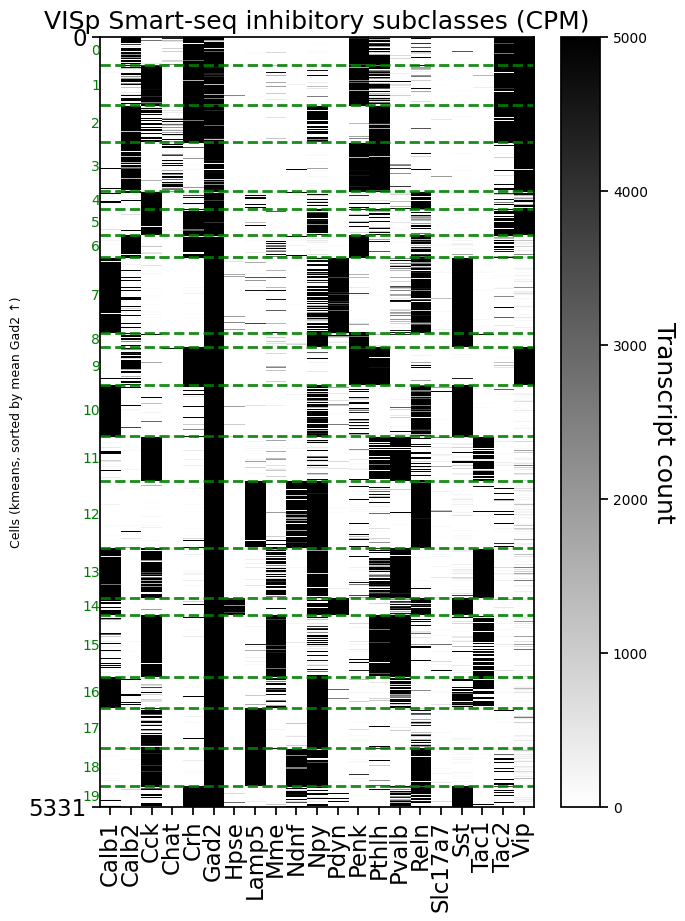

In [ ]:
import pandas as pd
import aind_hcr_qc.viz as viz

inh_cpm = filtered_cpm["inhibitory"]
viz.plot_cell_x_gene_clustered(
    pd.DataFrame(inh_cpm.X, columns=inh_cpm.var_names, index=inh_cpm.obs_names),
    k=20, fig_size=(7, 10), title="VISp Smart-seq inhibitory subclasses (CPM)",
    clip_range=(0, 5000))


(<Figure size 700x1000 with 2 Axes>,
 array([ 0,  0,  0, ..., 19, 19, 19], shape=(5331,)),
 Index(['F2S4_160119_005_F01', 'F2S4_160119_005_A01', 'F2S4_160121_001_G01',
        'F2S4_160119_009_C01', 'F2S4_171128_004_A01', 'F2S4_171128_001_G01',
        'F2S4_161017_001_G01', 'F2S4_161017_001_A01', 'F2S4_161017_004_C01',
        'F2S4_161017_003_D01',
        ...
        'F2S4_160404_019_B01', 'F2S4_170803_016_F01', 'F2S4_151223_016_F01',
        'F1S4_180124_308_E01', 'F1S4_180124_308_C01', 'F1S4_180124_307_H01',
        'F2S4_151223_017_B01', 'F2S4_160404_028_C01', 'F2S4_160404_029_H01',
        'F2S4_160404_032_F01'],
       dtype='object', name='sample_name', length=5331))

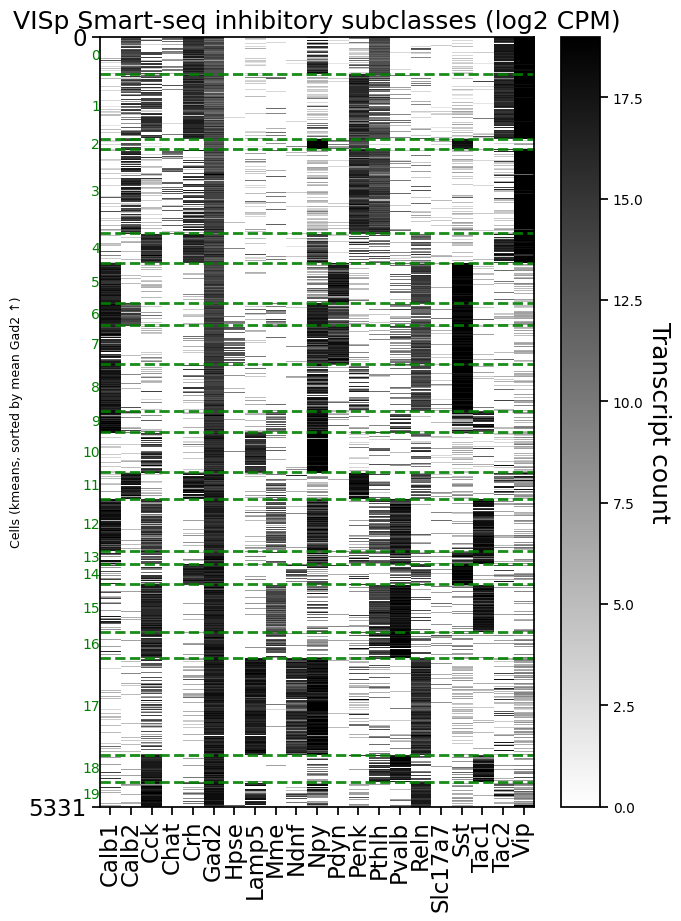

In [ ]:
import aind_hcr_qc.viz as viz
adata_log_inh = filtered_log["inhibitory"]
viz.plot_cell_x_gene_clustered(
    pd.DataFrame(adata_log_inh.X, columns=adata_log_inh.var_names, index=adata_log_inh.obs_names),
    k=20, fig_size=(7, 10), title="VISp Smart-seq inhibitory subclasses (log2 CPM)",
    clip_range=(0, 5000))


In [12]:
adata_log_inh.obs['cluster'].nunique()

62

# Plot cell x gene with tasic clusters

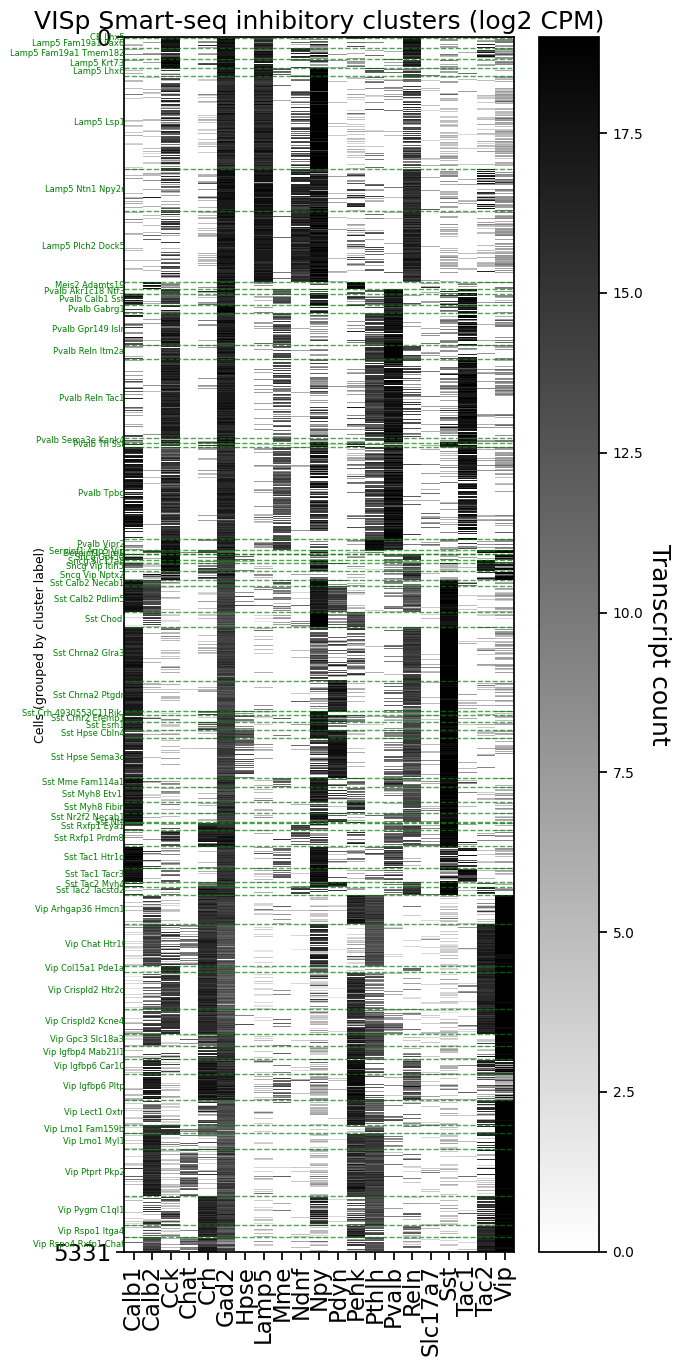

In [ ]:



fig, sorted_labels, sorted_ids = viz.plot_cell_x_gene_labeled(
    cxg_inh,
    labels=adata_log_inh.obs['cluster'],
    fig_size=(7, 14),
    clip_range=(0, 5000),
    label_fontsize=6,
    title="VISp Smart-seq inhibitory clusters (log2 CPM)",
)
plt.tight_layout()
plt.show()


# Explore by subclass

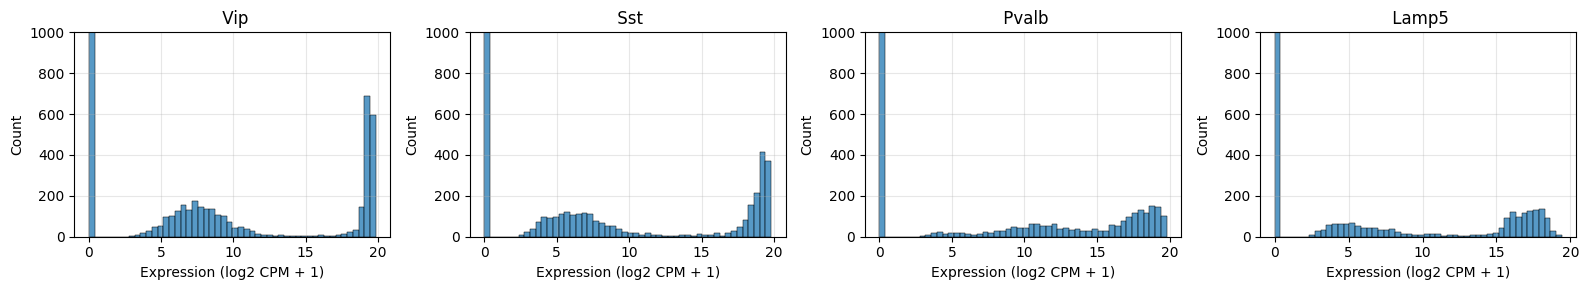

In [13]:
# Example: plot multiple inhibitory marker genes
example_genes = ["Vip", "Sst", "Pvalb", "Lamp5"]
fig = cluster_validation_utils.plot_gene_expression_subplots(adata_log_inh, example_genes, bins=50, ncols=4)
plt.show()

In [29]:
vip_mask = adata_log_inh[:, "Vip"].X.flatten() > 15
adata_log_inh_vip = adata_log_inh[vip_mask].copy()

In [33]:
# find best k
adata_log_inh = filtered_log["inhibitory"]
cxg_inh = pd.DataFrame(adata_log_inh_vip.X, columns=adata_log_inh_vip.var_names, index=adata_log_inh_vip.obs_names)

fig, k_results = viz.plot_kmeans_k_selection(
    cxg_vip,
    k_range=(2, 30),
    clip_range=(0, 5000),
    title="k-means k selection — inhibitory cells (log2 CPM)",
)
plt.show()

NameError: name 'cxg_vip' is not defined

(<Figure size 700x500 with 2 Axes>,
 array([0, 0, 0, ..., 6, 6, 6], shape=(1537,)),
 Index(['F2S4_160504_004_D01', 'F2S4_160502_019_C01', 'F2S4_160502_014_C01',
        'F2S4_170807_008_F01', 'F2S4_170807_008_C01', 'F1S4_180124_308_B01',
        'F1S4_170426_014_C01', 'F2S4_160419_003_C01', 'F2S4_160419_002_E01',
        'F2S4_160419_002_C01',
        ...
        'F2S4_160502_003_C01', 'F2S4_160516_005_G01', 'F2S4_160502_005_A01',
        'F2S4_160502_008_A01', 'F2S4_170807_007_E01', 'F2S4_151217_009_C01',
        'F2S4_151217_013_A01', 'F2S4_160502_009_C01', 'F2S4_160502_009_E01',
        'FYS4_171003_508_E01'],
       dtype='object', name='sample_name', length=1537))

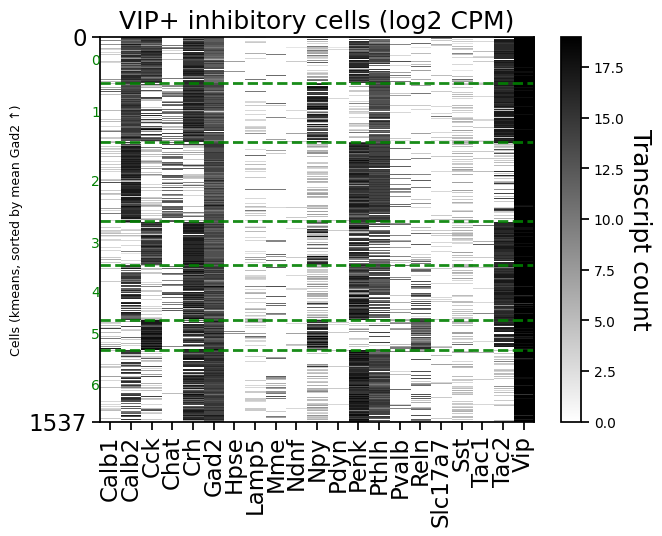

In [34]:
# redo clustering on cells with high VIP counts

viz.plot_cell_x_gene_clustered(
    pd.DataFrame(adata_log_inh_vip.X, columns=adata_log_inh_vip.var_names, index=adata_log_inh_vip.obs_names),
    k=7, fig_size=(7, 5), title="VIP+ inhibitory cells (log2 CPM)",
    clip_range=(0, 5000))


(<Figure size 700x500 with 2 Axes>,
 array([0, 0, 0, ..., 6, 6, 6], shape=(1537,)),
 Index(['F2S4_160504_004_D01', 'F2S4_160502_019_C01', 'F2S4_160502_014_C01',
        'F2S4_170807_008_F01', 'F2S4_170807_008_C01', 'F1S4_180124_308_B01',
        'F1S4_170426_014_C01', 'F2S4_160419_003_C01', 'F2S4_160419_002_E01',
        'F2S4_160419_002_C01',
        ...
        'F2S4_160502_003_C01', 'F2S4_160516_005_G01', 'F2S4_160502_005_A01',
        'F2S4_160502_008_A01', 'F2S4_170807_007_E01', 'F2S4_151217_009_C01',
        'F2S4_151217_013_A01', 'F2S4_160502_009_C01', 'F2S4_160502_009_E01',
        'FYS4_171003_508_E01'],
       dtype='object', name='sample_name', length=1537))

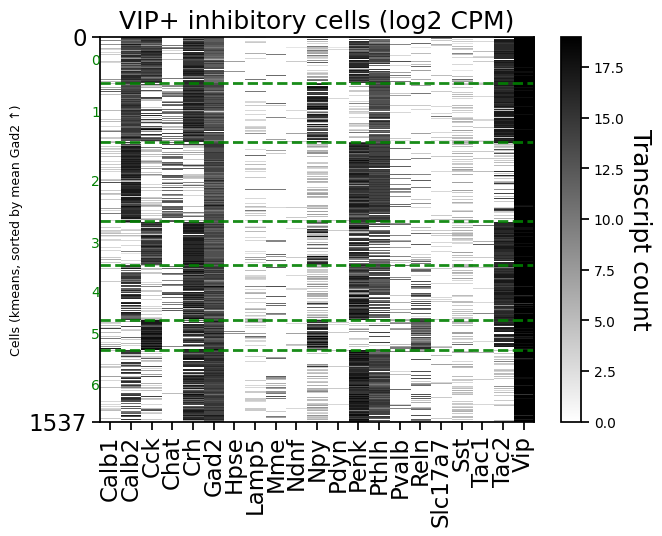

In [ ]:
# redo clustering on cells with high VIP counts

viz.plot_cell_x_gene_clustered(
    pd.DataFrame(adata_log_inh_vip.X, columns=adata_log_inh_vip.var_names, index=adata_log_inh_vip.obs_names),
    k=7, fig_size=(7, 5), title="VIP+ inhibitory cells (log2 CPM)",
    clip_range=(0, 5000))


/tmp/ipykernel_4185/1214755841.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="hsv")


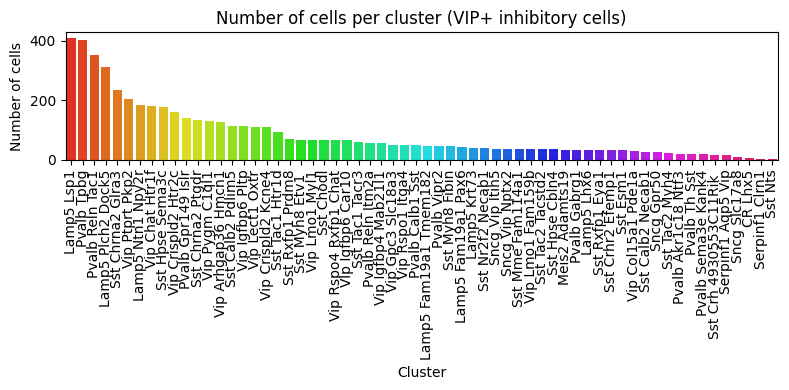

In [28]:
# make barplot for n cells per "cluster" in adata_log_inh, sort by n cells, rotate x labels, use rainbow palette
cluster_counts = adata_log_inh.obs['cluster'].value_counts().sort_index().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="hsv")
plt.xlabel("Cluster")
plt.ylabel("Number of cells")
plt.title("Number of cells per cluster (VIP+ inhibitory cells)")
plt.xticks(rotation=90)
plt.tight_layout()

In [33]:
adata_log_inh_subclass.obs['cluster'].value_counts().sort_values(ascending=False)

cluster
Sst Chrna2 Glra3          234
Sst Hpse Sema3c           177
Sst Chrna2 Ptgdr          134
Sst Calb2 Pdlim5          115
Sst Rxfp1 Prdm8            70
Sst Myh8 Etv1              68
Sst Chodl                  66
Sst Tac1 Htr1d             54
Sst Myh8 Fibin             46
Sst Nr2f2 Necab1           40
Sst Tac2 Tacstd2           37
Sst Mme Fam114a1           37
Sst Hpse Cbln4             36
Sst Rxfp1 Eya1             34
Sst Crhr2 Efemp1           32
Sst Esm1                   32
Sst Calb2 Necab1           27
Sst Tac1 Tacr3             26
Sst Tac2 Myh4              23
Pvalb Calb1 Sst            20
Pvalb Th Sst               19
Sst Crh 4930553C11Rik      17
Pvalb Reln Tac1             9
Pvalb Gabrg1                5
Sst Nts                     4
Pvalb Akr1c18 Ntf3          2
Pvalb Sema3e Kank4          1
Meis2 Adamts19              1
Sncg Vip Itih5              1
Name: count, dtype: int64

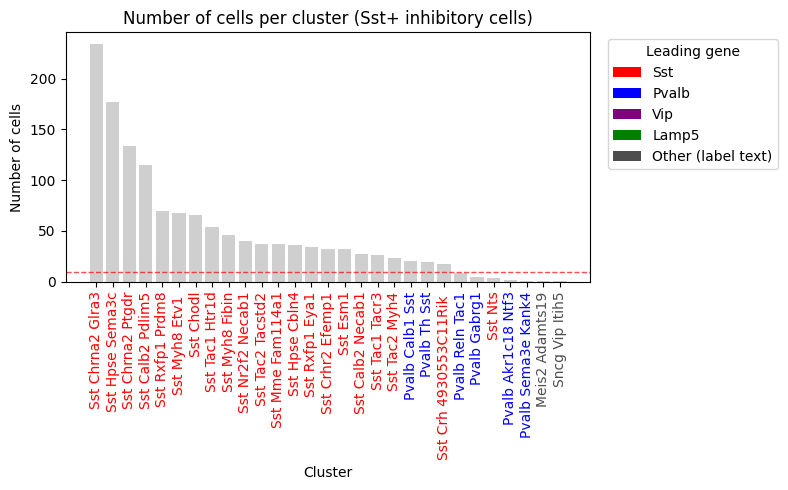

In [42]:
# make barplot for n cells per "cluster" in adata_log_inh_subclass, sorted by n cells
from matplotlib.patches import Patch

cluster_counts = adata_log_inh_subclass.obs['cluster'].value_counts().sort_values(ascending=False)

subclass_color_map = {
    "sst": "red",
    "pvalb": "blue",
    "vip": "purple",
    "lamp5": "green",
}

plt.figure(figsize=(8, 5))
ax = plt.gca()
# keep bars neutral; apply subclass colors to tick-label text
ax.bar(range(len(cluster_counts)), cluster_counts.values, color="#cfcfcf")
ax.set_xticks(range(len(cluster_counts)))
ax.set_xticklabels(cluster_counts.index, rotation=90)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of cells")
ax.set_title(f"Number of cells per cluster ({gene}+ inhibitory cells)")
ax.axhline(10, color="red", linestyle="--", label="10 cells", linewidth=1, alpha=0.7)

# Color label text by leading gene token (e.g., "Sst ...", "Pvalb ...")
cluster_validation_utils.color_axis_ticklabels(
    ax,
    axis="x",
    token_color_map=subclass_color_map,
    default_color="#4d4d4d",
    match_mode="leading_token",
)

legend_handles = [
    Patch(facecolor="red", label="Sst"),
    Patch(facecolor="blue", label="Pvalb"),
    Patch(facecolor="purple", label="Vip"),
    Patch(facecolor="green", label="Lamp5"),
    Patch(facecolor="#4d4d4d", label="Other (label text)"),
]
ax.legend(handles=legend_handles, title="Leading gene", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

In [43]:
# now filter out clusters with fewer than 10 cells from adata_log_inh_subclass
cluster_counts = adata_log_inh_subclass.obs['cluster'].value_counts()
clusters_to_keep = cluster_counts[cluster_counts >= 10].index
adata_log_inh_subclass_filtered = adata_log_inh_subclass[adata_log_inh_subclass.obs['cluster'].isin(clusters_to_keep)].copy()
print(f"Kept {adata_log_inh_subclass_filtered.n_obs} cells in {adata_log_inh_subclass_filtered.obs['cluster'].nunique()} clusters after filtering for >=10 cells/cluster")

Kept 1344 cells in 22 clusters after filtering for >=10 cells/cluster


Filtered to 1,367 cells with Sst > 15
After min cluster-size filter (cluster >= 10), kept 1,344 cells in 22 clusters
Best params: n_neighbors=80, resolution=0.5, ARI=0.336
Leiden found 8 clusters
UMAP computed


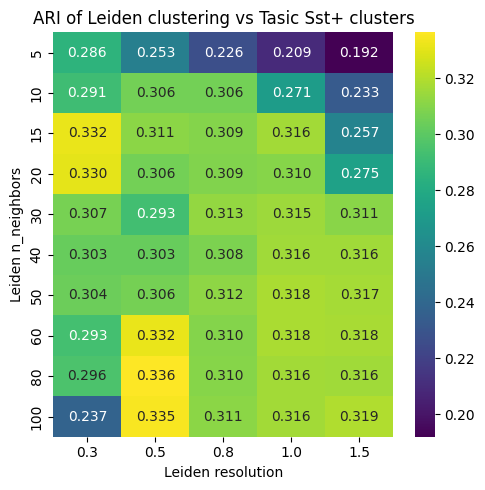

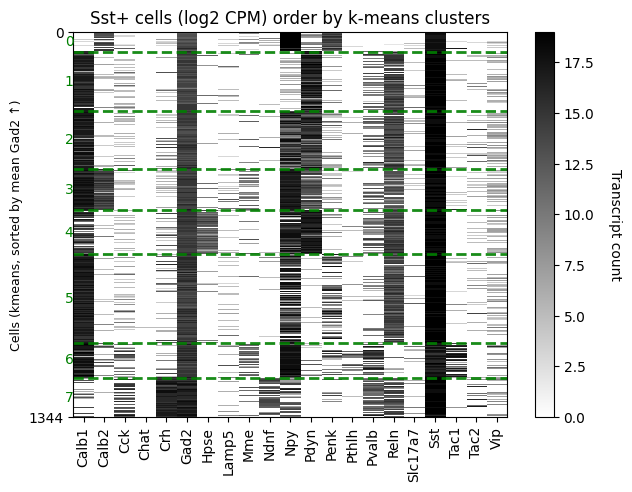

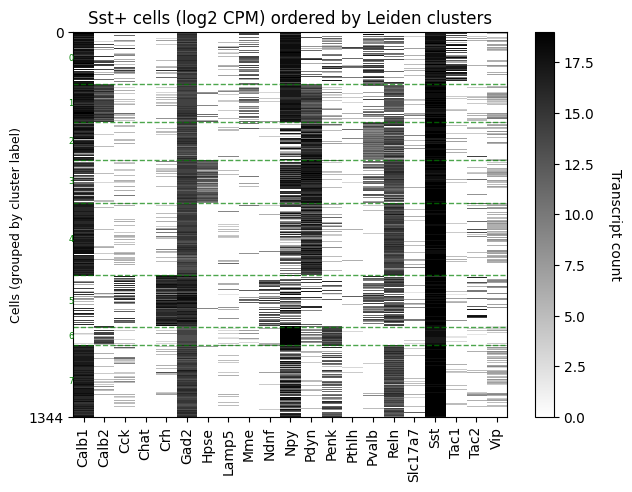

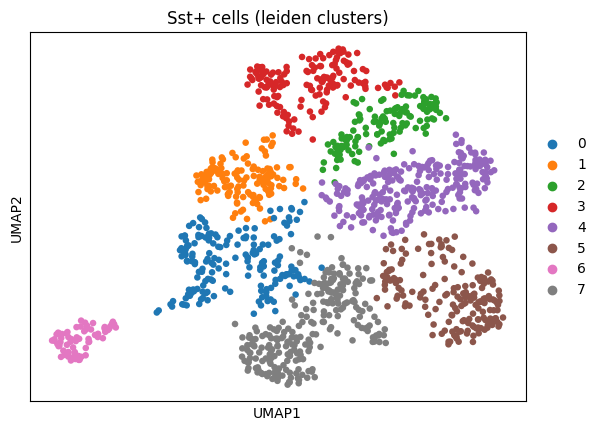

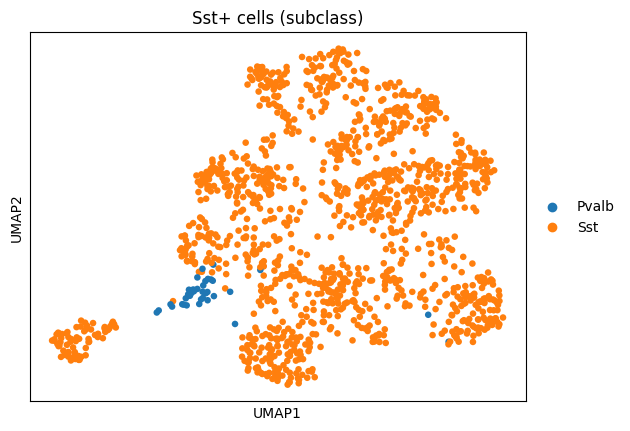

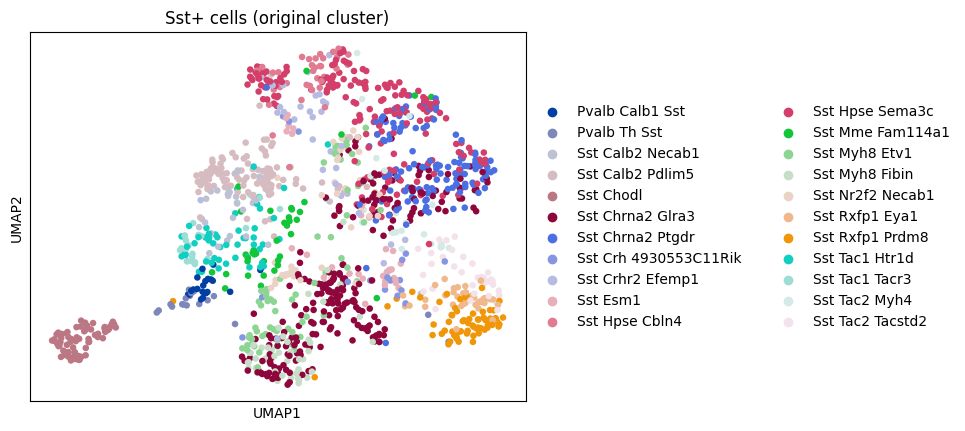

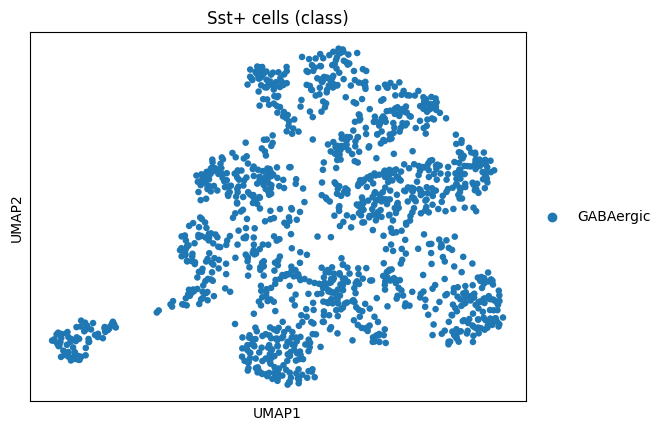

In [44]:
gene = "Sst"
expression_threshold = 15

# Use generic clustering function for subclass+ cells
adata_log_inh_subclass, subclass_results = cluster_validation_utils.cluster_gene_positive_cells(
    adata_log_inh,
    gene=gene,
    expression_threshold=expression_threshold,
    reference_cluster_col="cluster",
    min_cells_per_reference_cluster=10,
    compute_umap=True
)

# Plot parameter sweep heatmap
fig = cluster_validation_utils.plot_clustering_sweep_heatmap(
    subclass_results["sweep_df"],
    metric_col="ari",
    title=f"ARI of Leiden clustering vs Tasic {gene}+ clusters",
    figsize=(5, 5),
)
plt.show()

viz.plot_cell_x_gene_clustered(
    pd.DataFrame(adata_log_inh_subclass.X, columns=adata_log_inh_subclass.var_names, index=adata_log_inh_subclass.obs_names),
    k=subclass_results['n_clusters'], fig_size=(7, 5), title=f"{gene}+ cells (log2 CPM) order by k-means clusters",
    clip_range=(0, 5000))

# plot cell x gene with cells ordered by leiden cluster and genes ordered by original order use: viz.plot_cell_x_gene_labeled(
viz.plot_cell_x_gene_labeled(
    pd.DataFrame(adata_log_inh_subclass.X, columns=adata_log_inh_subclass.var_names, index=adata_log_inh_subclass.obs_names),
    labels=adata_log_inh_subclass.obs['leiden'], #col_labels=adata_log_inh_subclass.var_names,
    fig_size=(7, 5), title=f"{gene}+ cells (log2 CPM) ordered by Leiden clusters",
    clip_range=(0, 5000), label_fontsize=6)

# Plot UMAPs with different colorings
sc.pl.umap(adata_log_inh_subclass, color="leiden", title=f"{gene}+ cells (leiden clusters)")
sc.pl.umap(adata_log_inh_subclass, color="subclass", title=f"{gene}+ cells (subclass)")
sc.pl.umap(adata_log_inh_subclass, color="cluster", title=f"{gene}+ cells (original cluster)")
sc.pl.umap(adata_log_inh_subclass, color="class", title=f"{gene}+ cells (class)")


### Example: Use with other genes

The `cluster_gene_positive_cells()` function can be used with any gene. Examples:

```python
# SST+ cells
adata_sst, sst_results = cluster_validation_utils.cluster_gene_positive_cells(
    adata_log_inh, gene="Sst", expression_threshold=12
)

# Pvalb+ cells
adata_pvalb, pvalb_results = cluster_validation_utils.cluster_gene_positive_cells(
    adata_log_inh, gene="Pvalb", expression_threshold=10
)
```

## Old vs New cluster overlap diagnostics

Quantify how each original cluster label is distributed across new Leiden labels, then visualize new-cluster composition.

In [45]:
import cluster_validation_utils
from IPython.display import display

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the earlier clustering cell that creates this object.")

# Choose old/new label columns from adata_log_inh_subclass.obs
old_label_col = "cluster"      # original, more granular labels
new_label_col = "leiden"       # new labels

overlap = cluster_validation_utils.summarize_old_label_dispersion(
    adata_log_inh_subclass,
    old_label_col=old_label_col,
    new_label_col=new_label_col,
)

old_summary = overlap["old_label_summary"]

print("Old labels exclusive to exactly one new label:")
display(
    old_summary.loc[
        old_summary["is_exclusive_to_one_new_label"],
        ["old_label", "dominant_new_label", "n_cells", "dominant_fraction", "normalized_entropy"],
    ].sort_values(["n_cells", "dominant_fraction"], ascending=[False, False])
)

print("Most dispersed old labels across new labels:")
display(
    old_summary.loc[
        :, ["old_label", "n_new_labels_present", "normalized_entropy", "dominant_new_label", "dominant_fraction", "n_cells"]
    ].sort_values(["normalized_entropy", "n_new_labels_present", "n_cells"], ascending=[False, False, False]).head(20)
)

Old labels exclusive to exactly one new label:


,old_label,dominant_new_label,n_cells,dominant_fraction,normalized_entropy
0,Sst Chodl,6,66,1.0,-0.0
1,Sst Tac2 Tacstd2,5,37,1.0,-0.0
2,Sst Rxfp1 Eya1,5,34,1.0,-0.0
3,Pvalb Calb1 Sst,0,20,1.0,-0.0


Most dispersed old labels across new labels:


,old_label,n_new_labels_present,normalized_entropy,dominant_new_label,dominant_fraction,n_cells
16,Sst Crhr2 Efemp1,6,0.647776,3,0.562500,32
21,Sst Nr2f2 Necab1,5,0.634719,0,0.375000,40
20,Sst Esm1,4,0.595125,5,0.468750,32
18,Sst Myh8 Etv1,4,0.580630,7,0.514706,68
17,Sst Tac2 Myh4,4,0.530667,4,0.521739,23
15,Sst Crh 4930553C11Rik,4,0.524663,5,0.588235,17
19,Sst Hpse Sema3c,4,0.517047,3,0.485876,177
13,Sst Chrna2 Glra3,4,0.406765,7,0.641026,234
14,Sst Calb2 Necab1,3,0.384724,1,0.592593,27
11,Sst Mme Fam114a1,5,0.349443,0,0.810811,37


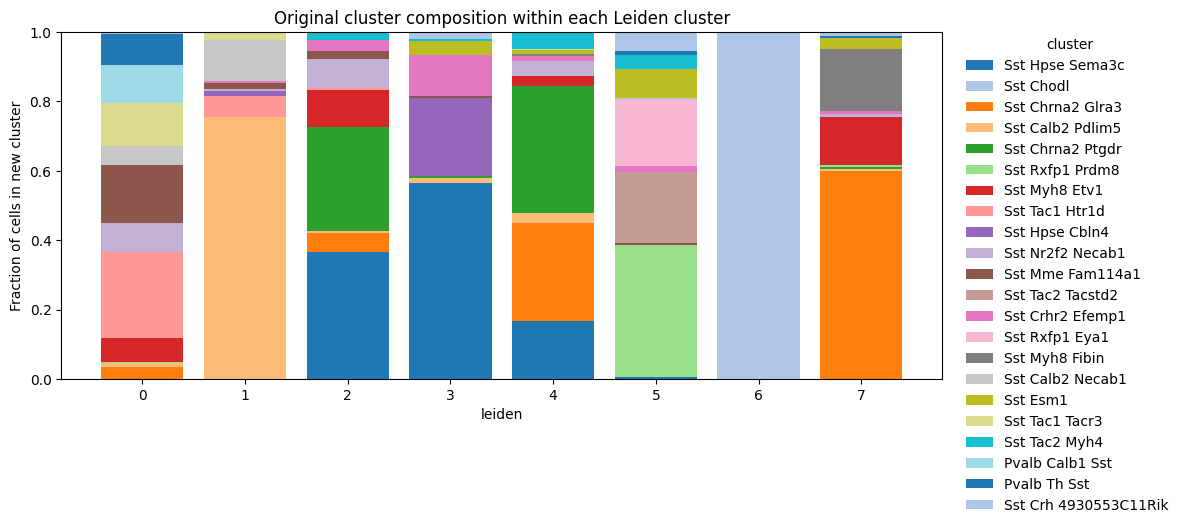

In [46]:
import matplotlib.pyplot as plt
import cluster_validation_utils

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the earlier clustering cell that creates this object.")

if "old_label_col" not in globals() or "new_label_col" not in globals():
    old_label_col = "cluster"
    new_label_col = "leiden"

# Stacked bar: composition of old labels within each new cluster
fig = cluster_validation_utils.plot_new_cluster_composition_stacked(
    adata_log_inh_subclass,
    old_label_col=old_label_col,
    new_label_col=new_label_col,
    normalize=True,
    min_fraction=0.02,   # fold very small old-label contributions into "Other"
    figsize=(12, 5),
    title="Original cluster composition within each Leiden cluster",
)
plt.show()

### Hierarchical overlap heatmap and enrichment view

These views highlight containment and cross-cluster mixing patterns:
- Fractional overlap heatmap (old labels by new labels) with hierarchical ordering
- log2 enrichment heatmap (observed/expected) to show selective over-representation

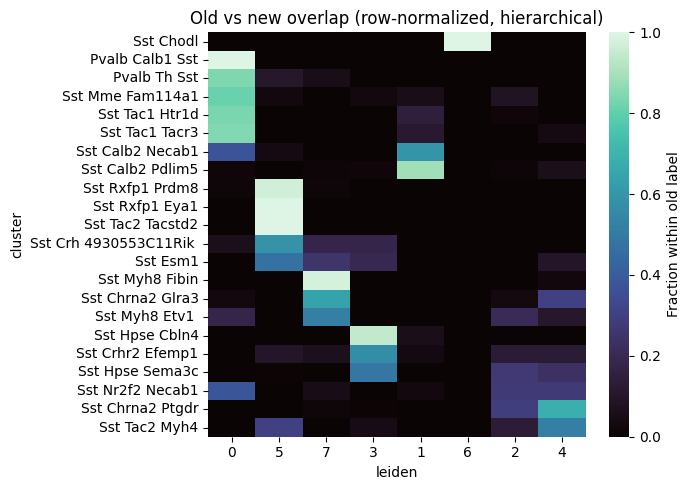

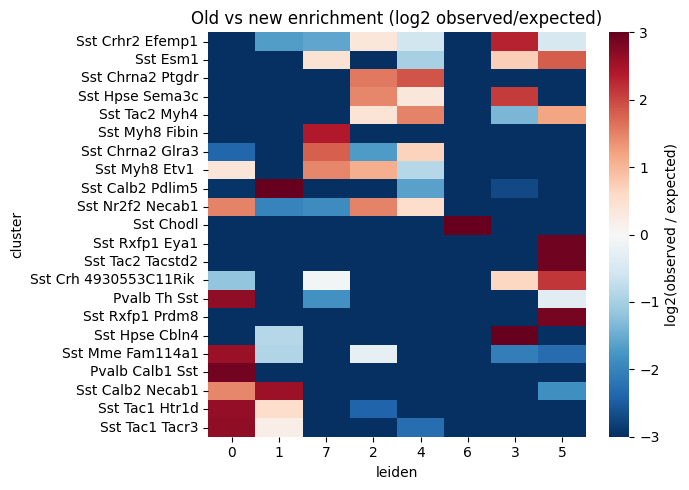

In [50]:
import matplotlib.pyplot as plt
import cluster_validation_utils

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the earlier clustering cell that creates this object.")

if "old_label_col" not in globals() or "new_label_col" not in globals():
    old_label_col = "cluster"
    new_label_col = "leiden"

# 1) Hierarchical overlap heatmap (fraction of each old label assigned to each new label)
fig = cluster_validation_utils.plot_old_new_overlap_heatmap_hierarchical(
    adata_log_inh_subclass,
    old_label_col=old_label_col,
    new_label_col=new_label_col,
    normalize="old",
    figsize=(7, 5),
    title="Old vs new overlap (row-normalized, hierarchical)",
)
plt.show()

# 2) Enrichment heatmap: highlights pairings stronger/weaker than expected by chance
fig = cluster_validation_utils.plot_old_new_log2_enrichment_heatmap(
    adata_log_inh_subclass,
    old_label_col=old_label_col,
    new_label_col=new_label_col,
    vmax_abs=3.0,
    figsize=(7, 5),
    title="Old vs new enrichment (log2 observed/expected)",
)
plt.show()

<string>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



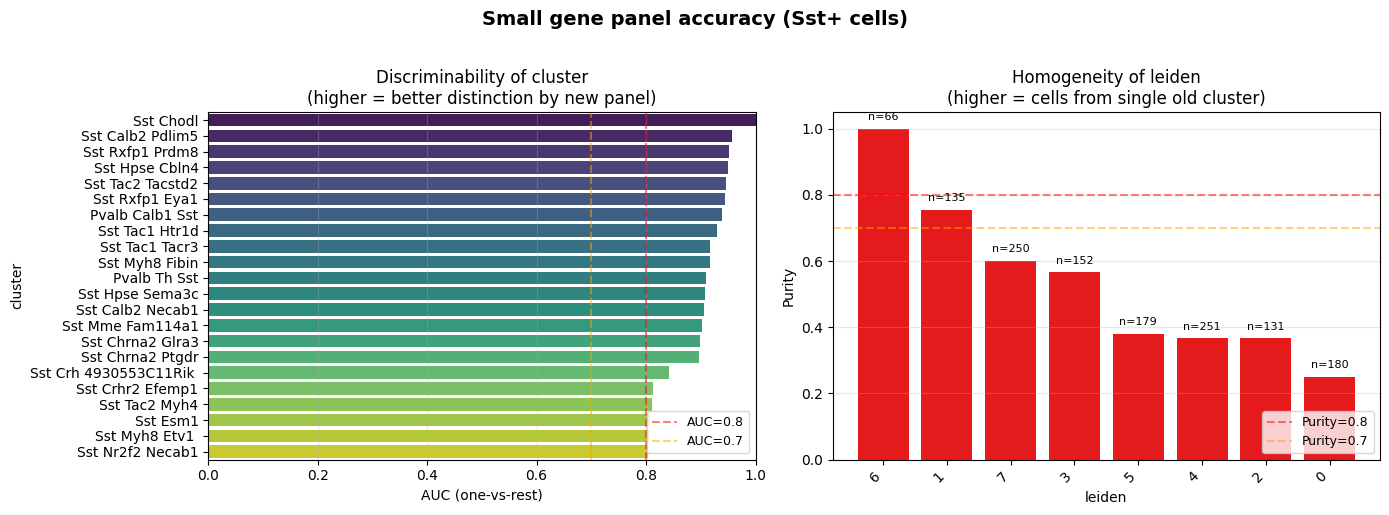


=== AUC per old label (discriminability) ===
Mean AUC: 0.898
Median AUC: 0.908
Std AUC: 0.058
High AUC (>0.8): 22 / 22 labels

Top 5 most distinguishable clusters:
Sst Chodl           1.000000
Sst Calb2 Pdlim5    0.957311
Sst Rxfp1 Prdm8     0.950785
Sst Hpse Cbln4      0.949563
Sst Tac2 Tacstd2    0.945677
dtype: float64

=== Purity per new label (homogeneity) ===
Mean purity: 0.536
Median purity: 0.473
Std purity: 0.248
High purity (>0.8): 1 / 8 clusters

Top 5 most homogeneous new clusters:
6    1.000000
1    0.755556
7    0.600000
3    0.565789
5    0.379888
dtype: float64


In [49]:
import matplotlib.pyplot as plt
import cluster_validation_utils

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the earlier clustering cell that creates this object.")

if "old_label_col" not in globals() or "new_label_col" not in globals():
    old_label_col = "cluster"
    new_label_col = "leiden"

# Plot accuracy metrics: AUC per old label + Purity per new label
fig, results = cluster_validation_utils.plot_accuracy_metrics_subplots(
    adata_log_inh_subclass,
    old_label_col=old_label_col,
    new_label_col=new_label_col,
    title_prefix=f"Small gene panel accuracy ({gene}+ cells)",
)
plt.show()

# Print summary statistics
print("\n=== AUC per old label (discriminability) ===")
auc_by_old = results['auc_per_old_label']
auc_series = pd.Series(auc_by_old).sort_values(ascending=False)
print(f"Mean AUC: {auc_series.mean():.3f}")
print(f"Median AUC: {auc_series.median():.3f}")
print(f"Std AUC: {auc_series.std():.3f}")
print(f"High AUC (>0.8): {(auc_series > 0.8).sum()} / {len(auc_series)} labels")
print(f"\nTop 5 most distinguishable clusters:")
print(auc_series.head(5))

print("\n=== Purity per new label (homogeneity) ===")
purity_by_new = results['purity_metrics']['purity_by_new_label']
purity_series = pd.Series(purity_by_new).sort_values(ascending=False)
print(f"Mean purity: {purity_series.mean():.3f}")
print(f"Median purity: {purity_series.median():.3f}")
print(f"Std purity: {purity_series.std():.3f}")
print(f"High purity (>0.8): {(purity_series > 0.8).sum()} / {len(purity_series)} clusters")
print(f"\nTop 5 most homogeneous new clusters:")
print(purity_series.head(5))

### k-NN soft-vote confidence

Measures per-cell confidence by looking at agreement among k nearest neighbours in gene expression space.
Works with **any** label source — pass `old_label_col` to ask *"how well does the small panel recover the original Tasic taxonomy?"* or `new_label_col` to measure new-cluster internal confidence.

- **Confidence** = max posterior P(top label | cell) — overall certainty
- **Margin** = P_top1 − P_top2 — how much better is the best label vs the runner-up (low margin = cell is ambiguous between two clusters)

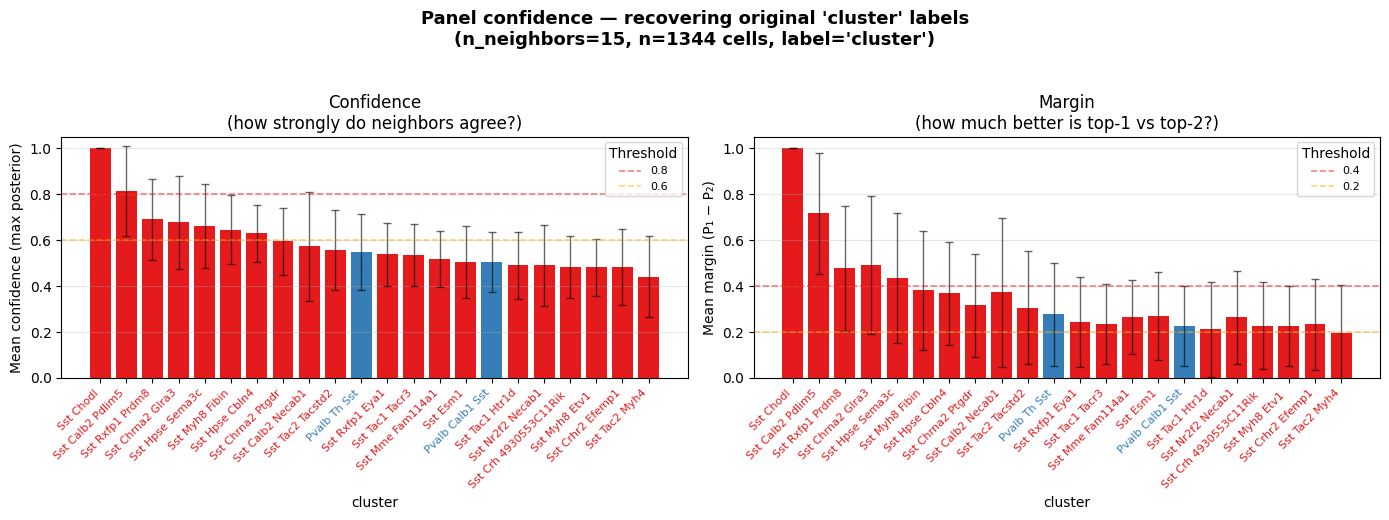

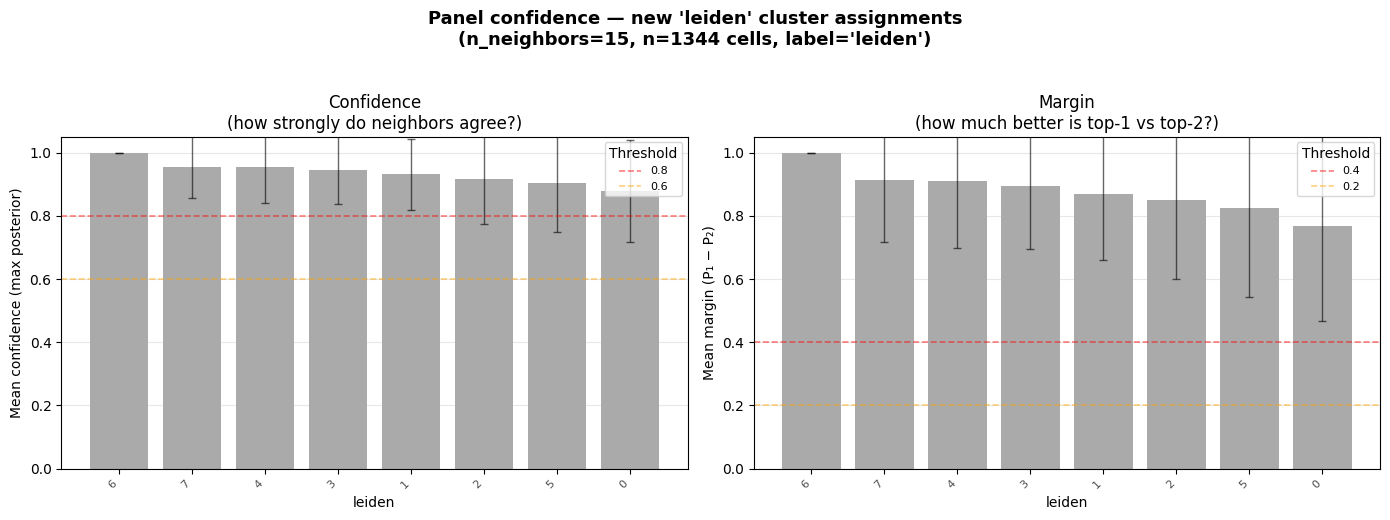

=== Confidence summary: recovering 'cluster' labels ===
  Mean confidence: 0.635  |  Median: 0.600
  Mean margin:     0.420  |  Median: 0.333
  Cells with conf > 0.8: 286 / 1344 (21.3%)
  Cells with conf < 0.5: 396 / 1344 (29.5%) ← ambiguous

=== Confidence summary: new 'leiden' clusters ===
  Mean confidence: 0.933  |  Median: 1.000
  Mean margin:     0.873  |  Median: 1.000
  Cells with conf > 0.8: 1121 / 1344 (83.4%)
  Cells with conf < 0.5: 14 / 1344 (1.0%) ← ambiguous


In [53]:
import matplotlib.pyplot as plt
import cluster_validation_utils

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the earlier clustering cell first.")

if "old_label_col" not in globals() or "new_label_col" not in globals():
    old_label_col = "cluster"
    new_label_col = "leiden"

# --- Option A: confidence at recovering OLD (Tasic) cluster labels ---
# Asks: "given only the ~20-gene panel, how well can a cell's original fine-grained identity be recovered?"
fig_old, soft_old = cluster_validation_utils.plot_knn_confidence_subplots(
    adata_log_inh_subclass,
    label_col=old_label_col,
    n_neighbors=15,
    title=f"Panel confidence — recovering original '{old_label_col}' labels",
)
plt.show()

# --- Option B: confidence of NEW (Leiden) cluster assignments ---
# Asks: "are the new clusters internally coherent in gene expression space?"
fig_new, soft_new = cluster_validation_utils.plot_knn_confidence_subplots(
    adata_log_inh_subclass,
    label_col=new_label_col,
    n_neighbors=15,
    title=f"Panel confidence — new '{new_label_col}' cluster assignments",
)
plt.show()

# Summary comparison
print(f"=== Confidence summary: recovering '{old_label_col}' labels ===")
old_conf = soft_old["_confidence"]
old_margin = soft_old["_margin"]
print(f"  Mean confidence: {old_conf.mean():.3f}  |  Median: {old_conf.median():.3f}")
print(f"  Mean margin:     {old_margin.mean():.3f}  |  Median: {old_margin.median():.3f}")
print(f"  Cells with conf > 0.8: {(old_conf > 0.8).sum()} / {len(old_conf)} ({(old_conf > 0.8).mean()*100:.1f}%)")
print(f"  Cells with conf < 0.5: {(old_conf < 0.5).sum()} / {len(old_conf)} ({(old_conf < 0.5).mean()*100:.1f}%) ← ambiguous")

print(f"\n=== Confidence summary: new '{new_label_col}' clusters ===")
new_conf = soft_new["_confidence"]
new_margin = soft_new["_margin"]
print(f"  Mean confidence: {new_conf.mean():.3f}  |  Median: {new_conf.median():.3f}")
print(f"  Mean margin:     {new_margin.mean():.3f}  |  Median: {new_margin.median():.3f}")
print(f"  Cells with conf > 0.8: {(new_conf > 0.8).sum()} / {len(new_conf)} ({(new_conf > 0.8).mean()*100:.1f}%)")
print(f"  Cells with conf < 0.5: {(new_conf < 0.5).sum()} / {len(new_conf)} ({(new_conf < 0.5).mean()*100:.1f}%) ← ambiguous")

### Top discriminable genes per Leiden cluster (with exclusions)

Given Leiden labels, rank the genes that best separate each cluster from the rest (one-vs-rest effect size).
Default exclusions remove broad markers `Gad2` and `Sst` so cluster-specific markers are emphasized.

Top 3 enriched and depleted genes per leiden cluster
Excluded genes: ('Gad2', 'Sst')
Bootstrap iterations: 100


,cluster,rank,gene,effect_size,mean_in,mean_out,std_all,n_in_cluster,n_out_cluster,direction,stability_pct
0,0,1,Reln,-1.401138,4.662170,12.391970,5.516800,180,1164,depleted,100.0
1,0,2,Pdyn,-1.015685,2.114433,9.810634,7.577349,180,1164,depleted,100.0
2,0,3,Hpse,-0.441848,0.052801,1.868928,4.110299,180,1164,depleted,79.0
3,0,1,Tac1,1.882654,8.573945,0.515895,4.280154,180,1164,enriched,100.0
4,0,2,Mme,1.104283,5.800844,1.233533,4.135996,180,1164,enriched,96.0
5,0,3,Pvalb,1.020625,9.855931,3.868010,5.866918,180,1164,enriched,85.0
6,1,1,Penk,-0.327927,2.043480,3.843507,5.489112,135,1209,depleted,96.0
7,1,2,Crh,-0.267504,1.778942,3.289109,5.645399,135,1209,depleted,67.0
8,1,3,Ndnf,-0.242745,0.352496,1.199660,3.489930,135,1209,depleted,51.0
9,1,1,Calb2,2.386889,14.226167,1.555162,5.308586,135,1209,enriched,100.0



Quick enriched marker table:


rank,cluster,top_enriched_1,top_enriched_2,top_enriched_3
0,0,Tac1,Mme,Pvalb
1,1,Calb2,Mme,Npy
2,2,Pvalb,Pdyn,Calb1
3,3,Hpse,Pdyn,Reln
4,4,Pdyn,Reln,Calb1
5,5,Crh,Ndnf,Cck
6,6,Penk,Calb2,Npy
7,7,Penk,Calb1,Reln



Quick depleted marker table:


rank,cluster,top_depleted_1,top_depleted_2,top_depleted_3
0,0,Reln,Pdyn,Hpse
1,1,Penk,Crh,Ndnf
2,2,Npy,Penk,Crh
3,3,Penk,Calb2,Tac1
4,4,Pvalb,Npy,Calb2
5,5,Calb1,Pdyn,Npy
6,6,Calb1,Reln,Pvalb
7,7,Pdyn,Pvalb,Mme



Bootstrap stability summary (% appearance in top-n):


,direction,cluster,mean_stability_pct
6,depleted,6,100.000000
7,depleted,7,95.666667
4,depleted,4,94.333333
0,depleted,0,93.000000
5,depleted,5,85.666667
2,depleted,2,79.333333
3,depleted,3,79.000000
1,depleted,1,71.333333
14,enriched,6,100.000000
15,enriched,7,100.000000


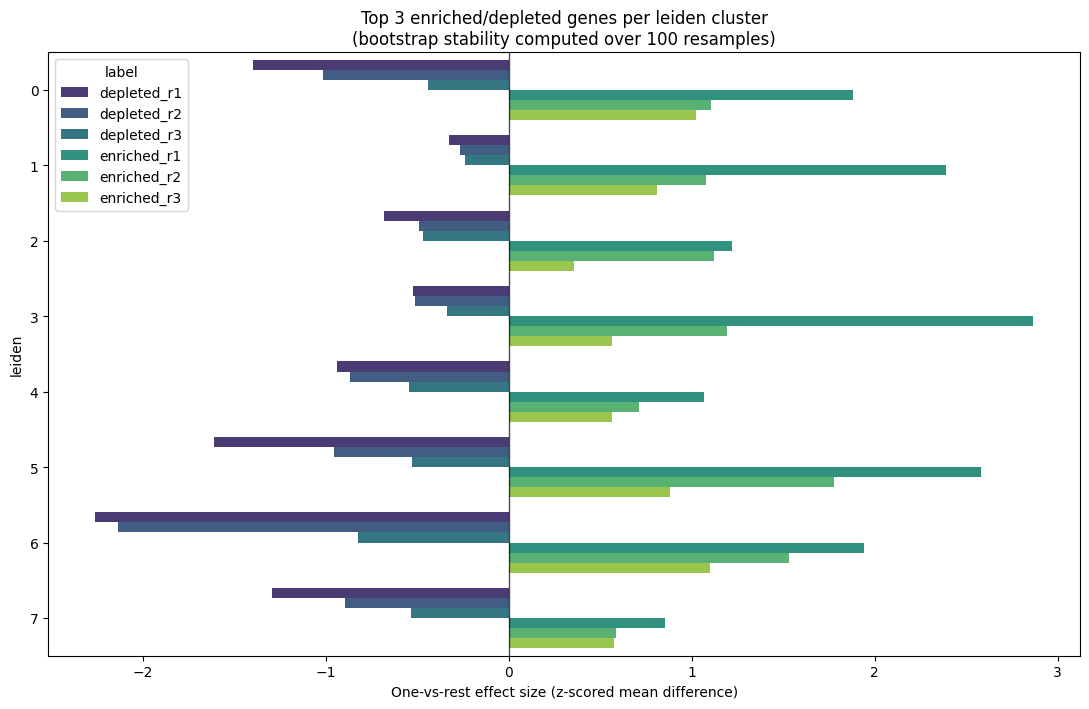

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cluster_validation_utils

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the clustering cell first.")

cluster_col = "leiden"
top_n = 3
exclude_genes = ("Gad2", "Sst")
bootstrap_iterations = 100

markers_df = cluster_validation_utils.top_discriminable_genes_per_cluster(
    adata_log_inh_subclass,
    cluster_col=cluster_col,
    top_n=top_n,
    exclude_genes=exclude_genes,
    use_abs_effect_size=False,
    include_depleted=True,
    bootstrap_iterations=bootstrap_iterations,
    random_state=0,
)

if markers_df.empty:
    print("No marker results returned.")
else:
    print(f"Top {top_n} enriched and depleted genes per {cluster_col} cluster")
    print(f"Excluded genes: {exclude_genes}")
    print(f"Bootstrap iterations: {bootstrap_iterations}")
    display(markers_df)

    # Compact tables for quick scan
    enriched_table = (
        markers_df[markers_df["direction"] == "enriched"]
        .pivot(index="cluster", columns="rank", values="gene")
        .rename(columns=lambda c: f"top_enriched_{c}")
        .reset_index()
    )
    depleted_table = (
        markers_df[markers_df["direction"] == "depleted"]
        .pivot(index="cluster", columns="rank", values="gene")
        .rename(columns=lambda c: f"top_depleted_{c}")
        .reset_index()
    )

    print("\nQuick enriched marker table:")
    display(enriched_table)
    print("\nQuick depleted marker table:")
    display(depleted_table)

    # Stability summary
    print("\nBootstrap stability summary (% appearance in top-n):")
    stability_summary = (
        markers_df.groupby(["direction", "cluster"], as_index=False)["stability_pct"]
        .mean()
        .rename(columns={"stability_pct": "mean_stability_pct"})
        .sort_values(["direction", "mean_stability_pct"], ascending=[True, False])
    )
    display(stability_summary)

    # Plot effect sizes, split by enriched vs depleted
    plot_df = markers_df.copy()
    plot_df["label"] = plot_df["direction"] + "_r" + plot_df["rank"].astype(str)

    plt.figure(figsize=(11, max(5, 0.45 * len(plot_df["cluster"].unique()) * 2)))
    ax = sns.barplot(
        data=plot_df,
        x="effect_size",
        y="cluster",
        hue="label",
        orient="h",
        palette="viridis",
    )
    ax.set_title(
        f"Top {top_n} enriched/depleted genes per {cluster_col} cluster\n"
        f"(bootstrap stability computed over {bootstrap_iterations} resamples)"
    )
    ax.set_xlabel("One-vs-rest effect size (z-scored mean difference)")
    ax.set_ylabel(cluster_col)
    ax.axvline(0, color="black", linewidth=1, alpha=0.7)
    plt.tight_layout()
    plt.show()

### High-confidence marker table (stability filtered)

Keep only markers that are consistently recovered by bootstrap (default `stability_pct >= 80`).
This gives a compact table for downstream annotation/reporting.

In [58]:
import pandas as pd
from pathlib import Path

if "markers_df" not in globals() or markers_df.empty:
    raise RuntimeError("markers_df is missing or empty. Run the previous marker-ranking cell first.")

# Stability threshold for high-confidence markers
stability_threshold = 80.0

high_conf_markers = markers_df[markers_df["stability_pct"] >= stability_threshold].copy()

if high_conf_markers.empty:
    print(f"No markers met stability threshold >= {stability_threshold:.1f}%")
else:
    # Create compact wide table with enriched/depleted top markers and their stability
    enriched_wide = (
        high_conf_markers[high_conf_markers["direction"] == "enriched"]
        .pivot(index="cluster", columns="rank", values="gene")
        .rename(columns=lambda c: f"enriched_top_{c}")
    )
    enriched_stab_wide = (
        high_conf_markers[high_conf_markers["direction"] == "enriched"]
        .pivot(index="cluster", columns="rank", values="stability_pct")
        .rename(columns=lambda c: f"enriched_top_{c}_stability_pct")
    )

    depleted_wide = (
        high_conf_markers[high_conf_markers["direction"] == "depleted"]
        .pivot(index="cluster", columns="rank", values="gene")
        .rename(columns=lambda c: f"depleted_top_{c}")
    )
    depleted_stab_wide = (
        high_conf_markers[high_conf_markers["direction"] == "depleted"]
        .pivot(index="cluster", columns="rank", values="stability_pct")
        .rename(columns=lambda c: f"depleted_top_{c}_stability_pct")
    )

    high_conf_table = (
        enriched_wide
        .join(enriched_stab_wide, how="outer")
        .join(depleted_wide, how="outer")
        .join(depleted_stab_wide, how="outer")
        .reset_index()
        .sort_values("cluster")
    )

    print(f"High-confidence markers (stability >= {stability_threshold:.1f}%)")
    display(high_conf_table)

    # Optional: long-form filtered table for stats/plots
    high_conf_long = (
        high_conf_markers
        .sort_values(["cluster", "direction", "rank"])
        .reset_index(drop=True)
    )
    print("\nHigh-confidence long-form table:")
    display(high_conf_long)

    # Optional CSV export
    export_csv = False
    if export_csv:
        out_dir = Path("/root/capsule/results")
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path_wide = out_dir / f"high_confidence_markers_{cluster_col}.csv"
        out_path_long = out_dir / f"high_confidence_markers_{cluster_col}_long.csv"
        high_conf_table.to_csv(out_path_wide, index=False)
        high_conf_long.to_csv(out_path_long, index=False)
        print(f"Saved: {out_path_wide}")
        print(f"Saved: {out_path_long}")

High-confidence markers (stability >= 80.0%)


rank,cluster,enriched_top_1,enriched_top_2,enriched_top_3,enriched_top_1_stability_pct,enriched_top_2_stability_pct,enriched_top_3_stability_pct,depleted_top_1,depleted_top_2,depleted_top_3,depleted_top_1_stability_pct,depleted_top_2_stability_pct,depleted_top_3_stability_pct
0,0,Tac1,Mme,Pvalb,100.0,96.0,85.0,Reln,Pdyn,NaN,100.0,100.0,NaN
1,1,Calb2,Mme,Npy,100.0,100.0,98.0,Penk,NaN,NaN,96.0,NaN,NaN
2,2,Pvalb,Pdyn,Calb1,100.0,100.0,84.0,Npy,NaN,NaN,99.0,NaN,NaN
3,3,Hpse,Pdyn,Reln,100.0,100.0,99.0,Penk,Calb2,NaN,100.0,100.0,NaN
4,4,Pdyn,Reln,Calb1,100.0,100.0,99.0,Pvalb,Npy,Calb2,100.0,100.0,83.0
5,5,Crh,Ndnf,Cck,100.0,100.0,91.0,Calb1,Pdyn,NaN,100.0,100.0,NaN
6,6,Penk,Calb2,Npy,100.0,100.0,100.0,Calb1,Reln,Pvalb,100.0,100.0,100.0
7,7,Penk,Calb1,Reln,100.0,100.0,100.0,Pdyn,Pvalb,Mme,100.0,100.0,87.0



High-confidence long-form table:


,cluster,rank,gene,effect_size,mean_in,mean_out,std_all,n_in_cluster,n_out_cluster,direction,stability_pct
0,0,1,Reln,-1.401138,4.662170,12.391970,5.516800,180,1164,depleted,100.0
1,0,2,Pdyn,-1.015685,2.114433,9.810634,7.577349,180,1164,depleted,100.0
2,0,1,Tac1,1.882654,8.573945,0.515895,4.280154,180,1164,enriched,100.0
3,0,2,Mme,1.104283,5.800844,1.233533,4.135996,180,1164,enriched,96.0
4,0,3,Pvalb,1.020625,9.855931,3.868010,5.866918,180,1164,enriched,85.0
5,1,1,Penk,-0.327927,2.043480,3.843507,5.489112,135,1209,depleted,96.0
6,1,1,Calb2,2.386889,14.226167,1.555162,5.308586,135,1209,enriched,100.0
7,1,2,Mme,1.076236,5.849417,1.398108,4.135996,135,1209,enriched,100.0
8,1,3,Npy,0.811411,17.288840,12.089288,6.408038,135,1209,enriched,98.0
9,2,1,Npy,-0.681322,8.671178,13.037113,6.408038,131,1213,depleted,99.0


### Cluster string labels from enriched markers

Build a compact label per cluster by concatenating top enriched genes that pass the stability threshold.
This produces a reusable cluster-to-label mapping table.

In [60]:
import pandas as pd
from pathlib import Path

if "high_conf_markers" not in globals() or high_conf_markers.empty:
    raise RuntimeError("high_conf_markers is missing or empty. Run the high-confidence marker table cell first.")

# How many enriched genes to include in each string label
n_label_genes = 3
label_sep = " | "

enriched_for_labels = (
    high_conf_markers[
        (high_conf_markers["direction"] == "enriched") &
        (high_conf_markers["rank"] <= n_label_genes)
    ]
    .sort_values(["cluster", "rank"])
    .copy()
)

if enriched_for_labels.empty:
    print("No enriched markers available for label string assignment.")
else:
    # Build gene string per cluster, e.g. "Tac1 | Mme | Pvalb"
    cluster_label_table = (
        enriched_for_labels
        .groupby("cluster", as_index=False)
        .agg(
            cluster_label_string=("gene", lambda s: label_sep.join(s.astype(str).tolist())),
            marker_count=("gene", "count"),
            mean_label_stability_pct=("stability_pct", "mean"),
            min_label_stability_pct=("stability_pct", "min"),
        )
        .sort_values("cluster")
        .reset_index(drop=True)
    )

    print(f"Cluster string labels from top {n_label_genes} enriched genes")
    display(cluster_label_table)

    # Optional: include per-rank gene/stability columns for traceability
    label_detail_wide = (
        enriched_for_labels
        .pivot(index="cluster", columns="rank", values="gene")
        .rename(columns=lambda c: f"label_gene_{c}")
    )
    stability_detail_wide = (
        enriched_for_labels
        .pivot(index="cluster", columns="rank", values="stability_pct")
        .rename(columns=lambda c: f"label_gene_{c}_stability_pct")
    )
    cluster_label_detailed = (
        cluster_label_table
        .merge(label_detail_wide.reset_index(), on="cluster", how="left")
        .merge(stability_detail_wide.reset_index(), on="cluster", how="left")
    )

    print("\nDetailed cluster label mapping:")
    display(cluster_label_detailed)

    # Optional CSV export
    export_label_csv = False
    if export_label_csv:
        out_dir = Path("/root/capsule/results")
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"cluster_string_labels_{cluster_col}.csv"
        cluster_label_detailed.to_csv(out_path, index=False)
        print(f"Saved: {out_path}")

Cluster string labels from top 3 enriched genes


,cluster,cluster_label_string,marker_count,mean_label_stability_pct,min_label_stability_pct
0,0,Tac1 | Mme | Pvalb,3,93.666667,85.0
1,1,Calb2 | Mme | Npy,3,99.333333,98.0
2,2,Pvalb | Pdyn | Calb1,3,94.666667,84.0
3,3,Hpse | Pdyn | Reln,3,99.666667,99.0
4,4,Pdyn | Reln | Calb1,3,99.666667,99.0
5,5,Crh | Ndnf | Cck,3,97.000000,91.0
6,6,Penk | Calb2 | Npy,3,100.000000,100.0
7,7,Penk | Calb1 | Reln,3,100.000000,100.0



Detailed cluster label mapping:


,cluster,cluster_label_string,marker_count,mean_label_stability_pct,min_label_stability_pct,label_gene_1,label_gene_2,label_gene_3,label_gene_1_stability_pct,label_gene_2_stability_pct,label_gene_3_stability_pct
0,0,Tac1 | Mme | Pvalb,3,93.666667,85.0,Tac1,Mme,Pvalb,100.0,96.0,85.0
1,1,Calb2 | Mme | Npy,3,99.333333,98.0,Calb2,Mme,Npy,100.0,100.0,98.0
2,2,Pvalb | Pdyn | Calb1,3,94.666667,84.0,Pvalb,Pdyn,Calb1,100.0,100.0,84.0
3,3,Hpse | Pdyn | Reln,3,99.666667,99.0,Hpse,Pdyn,Reln,100.0,100.0,99.0
4,4,Pdyn | Reln | Calb1,3,99.666667,99.0,Pdyn,Reln,Calb1,100.0,100.0,99.0
5,5,Crh | Ndnf | Cck,3,97.000000,91.0,Crh,Ndnf,Cck,100.0,100.0,91.0
6,6,Penk | Calb2 | Npy,3,100.000000,100.0,Penk,Calb2,Npy,100.0,100.0,100.0
7,7,Penk | Calb1 | Reln,3,100.000000,100.0,Penk,Calb1,Reln,100.0,100.0,100.0


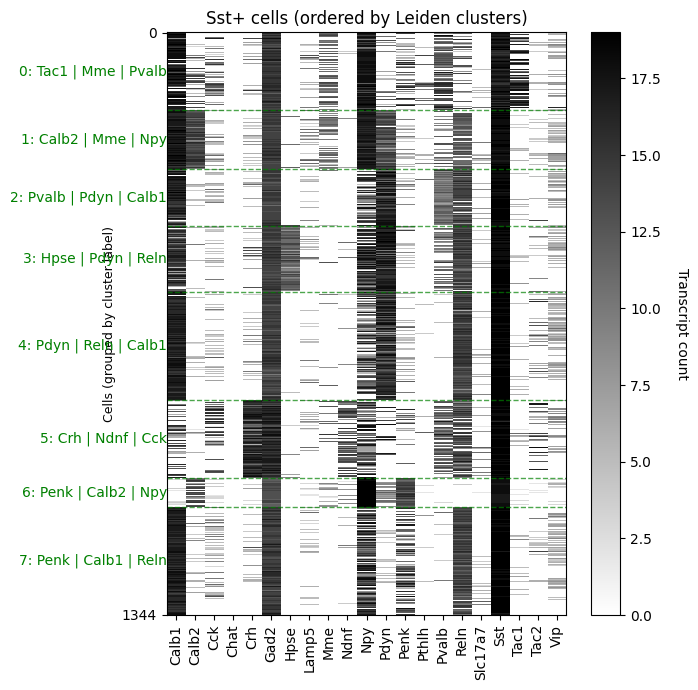

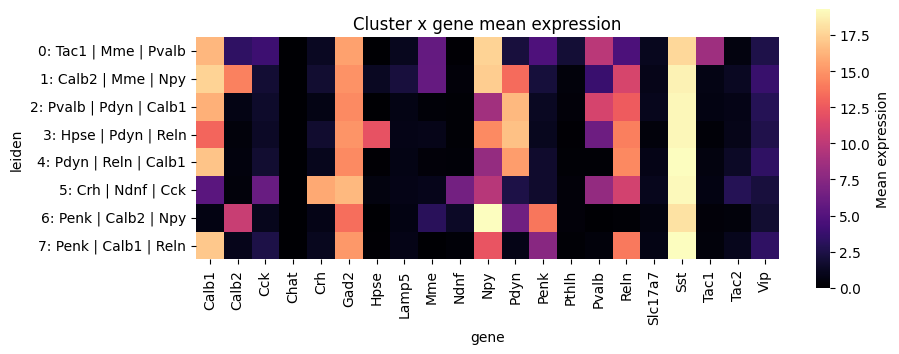

Per-cluster mean expression table (first 5 rows):


gene_symbol,Calb1,Calb2,Cck,Chat,Crh,Gad2,Hpse,Lamp5,Mme,Ndnf,...,Pdyn,Penk,Pthlh,Pvalb,Reln,Slc17a7,Sst,Tac1,Tac2,Vip
_cluster,,,,,,,,,,,,,,,,,,,,,
0,16.370321,3.358097,3.952837,0.000000,1.219821,15.479054,0.052801,1.128474,5.800844,0.083506,...,2.114433,4.683027,1.902227,9.855931,4.662170,1.095477,17.779459,8.573945,0.557032,2.504793
1,17.527201,14.226168,1.840717,0.000000,1.778943,14.903395,1.263012,2.112202,5.849417,0.352496,...,13.274533,2.043481,0.432736,3.833118,11.220206,0.868686,18.791803,0.688645,1.219830,3.763384
2,16.078548,0.728138,1.575728,0.000000,0.735723,14.553732,0.045857,0.748291,0.284748,0.215171,...,16.450520,1.227881,0.332774,11.121428,12.638258,1.013449,19.024504,0.642035,0.811753,2.890259
3,13.110133,0.406358,1.386380,0.000000,1.687226,14.975926,12.071156,0.798782,0.903073,0.185132,...,16.790375,1.111419,0.122979,6.200207,14.114753,0.429108,19.028551,0.301529,0.867357,2.574246
4,16.959688,0.467552,1.792463,0.039065,1.054879,14.613884,0.150218,0.721970,0.334564,0.242678,...,15.357493,1.636084,0.194103,0.181652,14.547248,0.780530,19.242598,0.541890,1.385091,3.368970


In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import aind_hcr_qc.viz as viz

if "adata_log_inh_subclass" not in globals():
    raise RuntimeError("adata_log_inh_subclass is not defined. Run the clustering cell first.")

cluster_col = "leiden"

# Build labels for cell x gene plot (use cluster_label_string when available)
labels_for_plot = adata_log_inh_subclass.obs[cluster_col].astype(str).copy()
label_map = {}
if "cluster_label_detailed" in globals() and not cluster_label_detailed.empty:
    label_map = dict(
        zip(
            cluster_label_detailed["cluster"].astype(str),
            cluster_label_detailed["cluster_label_string"].astype(str),
        )
    )
    labels_for_plot = labels_for_plot.map(lambda x: f"{x}: {label_map.get(x, x)}")

cxg_sub = pd.DataFrame(
    adata_log_inh_subclass.X,
    columns=adata_log_inh_subclass.var_names,
    index=adata_log_inh_subclass.obs_names,
)

# Cluster x gene mean expression table
mean_expr_by_cluster = (
    cxg_sub.assign(_cluster=adata_log_inh_subclass.obs[cluster_col].astype(str).values)
    .groupby("_cluster")
    .mean()
)
mean_expr_plot = mean_expr_by_cluster.copy()
mean_expr_plot.index = [f"{c}: {label_map.get(c, c)}" for c in mean_expr_plot.index.astype(str)]

# Plot 1: cell x gene (viz format)
# NOTE: fig_size only applies when ax is NOT passed.
fig1, _, _ = viz.plot_cell_x_gene_labeled(
    cxg_sub,
    labels=labels_for_plot,
    clip_range=(0, 30),
    fig_size=(7, 7),
    label_fontsize=10,
    title=f"{gene}+ cells (ordered by Leiden clusters)",
)
fig1.axes[0].set_xlabel("")
plt.tight_layout()
plt.show()

# Plot 2: cluster x gene mean-expression heatmap with square cells
n_rows, n_cols = mean_expr_plot.shape
fig2_w = max(8, 0.45 * n_cols)
fig2_h = max(4, 0.45 * n_rows)
fig2, ax2 = plt.subplots(figsize=(fig2_w, fig2_h))
sns.heatmap(
    mean_expr_plot,
    ax=ax2,
    cmap="magma",
    square=True,
    cbar_kws={"label": "Mean expression", "shrink": 0.85},
)
ax2.set_title("Cluster x gene mean expression")
ax2.set_xlabel("gene")
ax2.set_ylabel(cluster_col)
ax2.tick_params(axis="x", labelrotation=90)
ax2.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()

print("Per-cluster mean expression table (first 5 rows):")
display(mean_expr_by_cluster.head())